In [1]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import scipy
from itertools import combinations

In [2]:
sys.path.insert(0, "src")

from grn import grn

np.random.seed(5)


In [3]:
#manually adjust GRN hyperparameters in an attempt to build GRN with more non-additive effects
G = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.99,       # 1 - 1/r
    gamma=0.01,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=100,
)

In [4]:
G.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=True,
)
x_wt = np.zeros(256)
y_wt = G.rna

In [6]:
single_ko_expression = np.zeros((G.n, G.n))
single_ko_logfc = np.zeros((G.n, G.n))
single_ko_convergence = {}

for gene in tqdm(range(G.n), desc="Simulating single-gene KOs"):
    
    result = G.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    single_ko_expression[gene, :] = result["new_rna"].flatten()
    single_ko_logfc[gene, :] = result["logfc"].flatten()
    single_ko_convergence[gene] = result['convergence']
x_single_ko = np.eye(G.n)
y_single_ko = single_ko_expression

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

In [8]:
pairs = list(combinations(range(G.n), 2))

n_jobs = 64

def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results = Parallel(
    n_jobs=16,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_expression = np.asarray(
    [r[0] for r in results],
    dtype=np.float32
)

double_logfc = np.asarray(
    [r[1] for r in results],
    dtype=np.float32
)
double_convergence = np.asarray(
    [r[2] for r in results],
    dtype=np.float32
)



#now prepare as training data

pairs = np.array(
    pairs,
    dtype=np.int32
)

x_double_ko = np.zeros((pairs.shape[0], G.n))

#now fill x for doubleKO with 1s

rows = np.arange(pairs.shape[0])
x_double_ko[rows, pairs[:, 0]] = 1.0
x_double_ko[rows, pairs[:, 1]] = 1.0

y_double_ko = double_expression

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    3.1s
[Parallel(n_jobs=16)]: Done  16 tasks      | elapsed:    3.5s
[Parallel(n_jobs=16)]: Done  25 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done  34 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  45 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done  56 tasks      | elapsed:    5.1s
[Parallel(n_jobs=16)]: Done  69 tasks      | elapsed:    5.5s
[Parallel(n_jobs=16)]: Done  82 tasks      | elapsed:    6.0s
[Parallel(n_jobs=16)]: Done  97 tasks      | elapsed:    6.6s
[Parallel(n_jobs=16)]: Done 112 tasks      | elapsed:    7.3s
[Parallel(n_jobs=16)]: Done 129 tasks      | elapsed:    8.0s
[Parallel(n_jobs=16)]: Done 146 tasks      | elapsed:    8.6s
[Parallel(n_jobs=16)]: Done 165 tasks      | elapsed:    9.3s
[Parallel(n_jobs=16)]: Done 184 tasks      | elapsed:  

/home/jovyan/my-conda-envs/grn_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


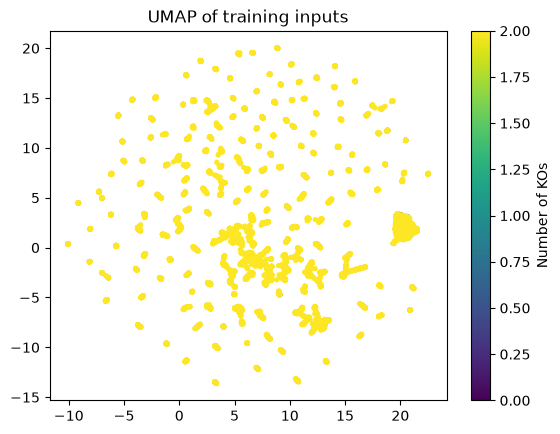

In [13]:
from umap import UMAP
import matplotlib.pyplot as plt

z = UMAP(random_state=42).fit_transform(ytr)
plt.scatter(z[:, 0], z[:, 1], c=xtr.sum(1), s=8, cmap="viridis")
plt.colorbar(label="Number of KOs")
plt.title("UMAP of training inputs")
plt.show()

/home/jovyan/my-conda-envs/grn_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


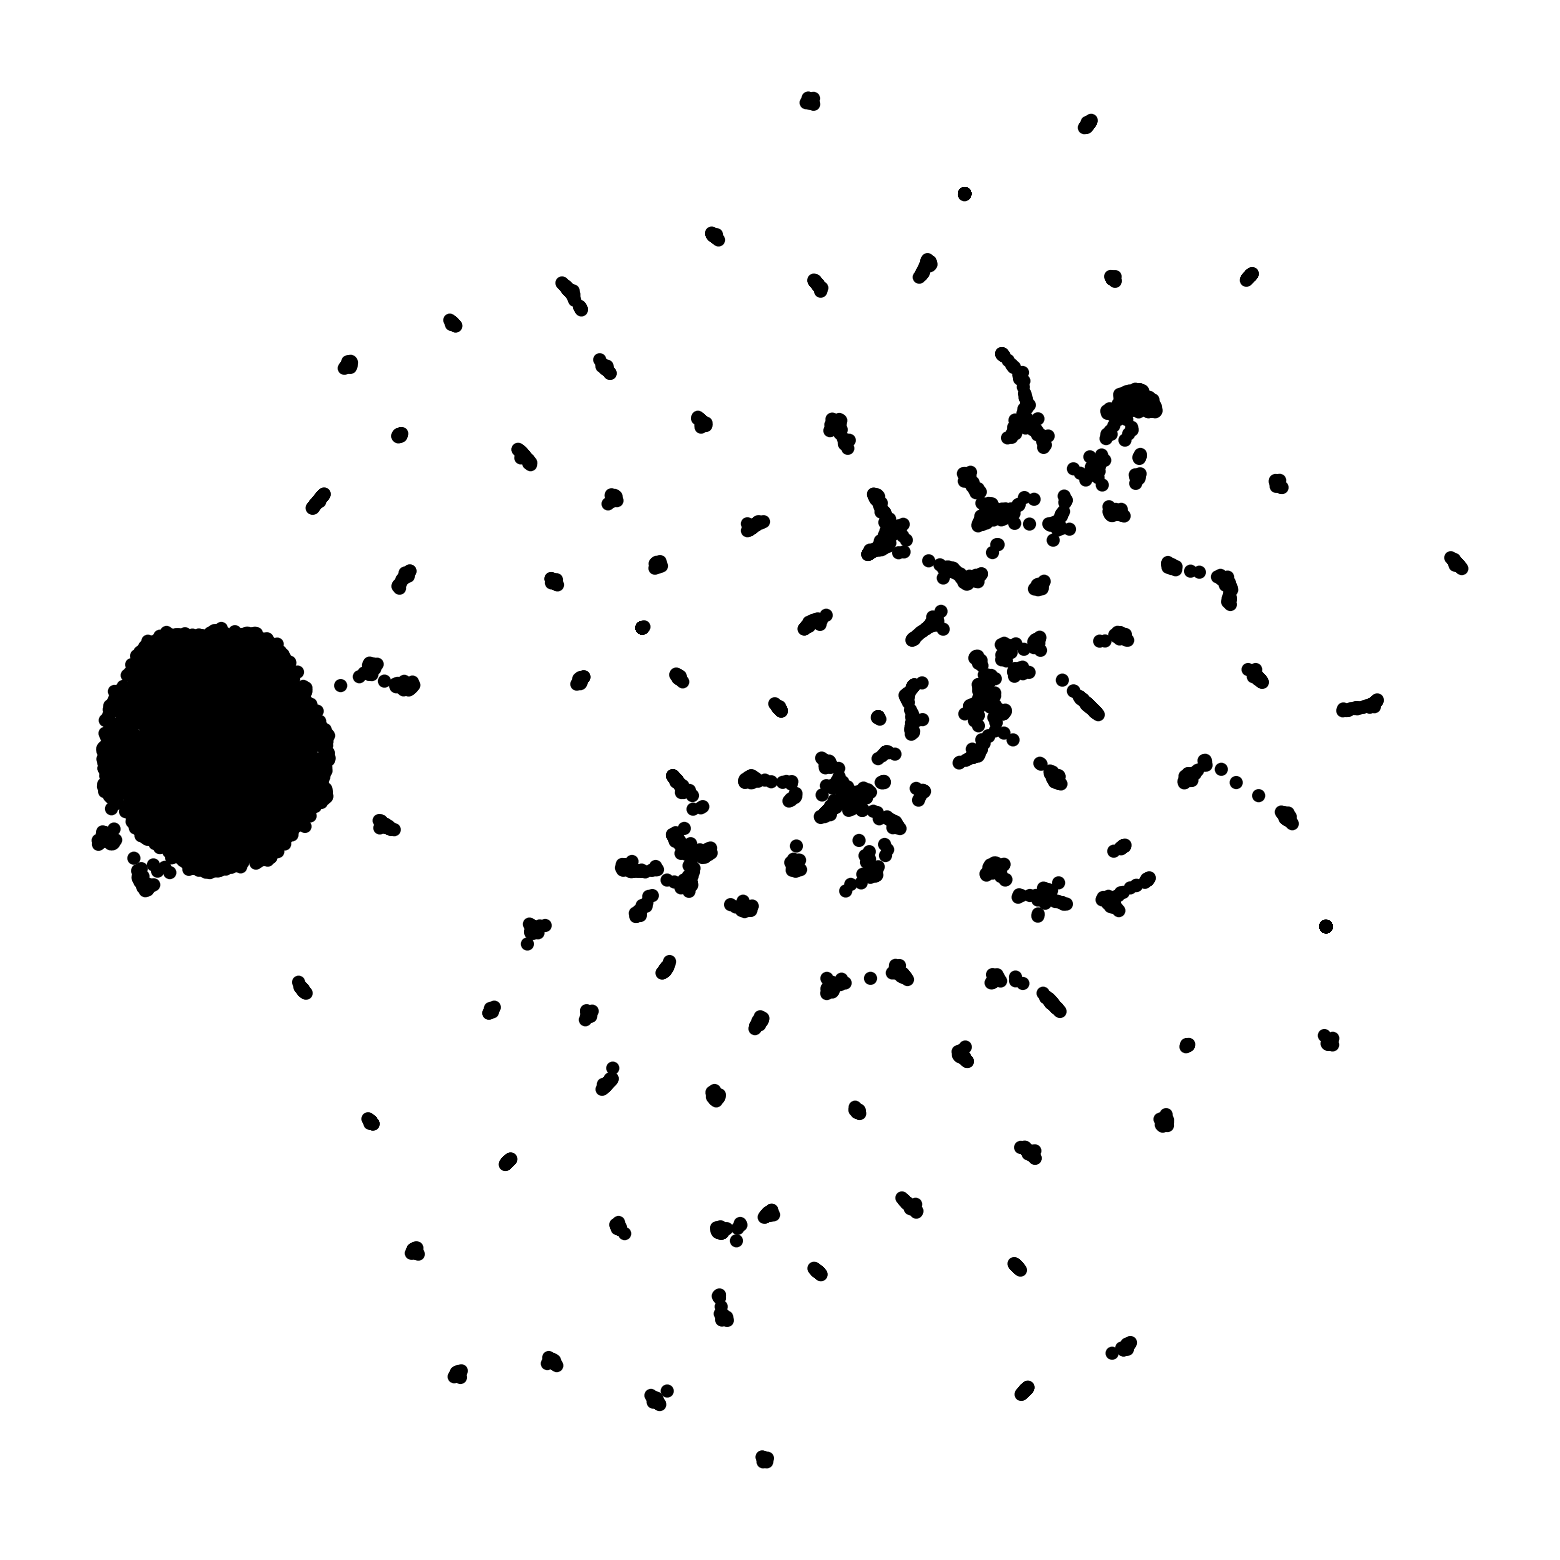

In [13]:
from umap import UMAP
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# UMAP on training inputs
z = UMAP(random_state=42).fit_transform(s_ytr)

# 0=WT, 1=single KO, 2=double KO
labels = s_ytr.sum(1)

# clean 3-color palette from your colors
cmap = ListedColormap(["#000000"])

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
ax.scatter(z[:, 0], z[:, 1], c=labels, cmap=cmap, s=10, linewidths=0)

ax.set_axis_off()
plt.tight_layout(pad=0)

# best for posters
plt.savefig("umap_training_data.svg", bbox_inches="tight", pad_inches=0, transparent=True)
plt.savefig("umap_training_data.pdf", bbox_inches="tight", pad_inches=0, transparent=True)
plt.savefig("umap_training_data.png", dpi=600, bbox_inches="tight", pad_inches=0, transparent=True)

plt.show()

# Lets train MLP on toy 256 gene GRN

In [10]:
seed = 0

import torch
from torch import nn
torch.manual_seed(seed)
device = torch.device('cpu')
#for more precision
#torch.backends.cuda.matmul.allow_tf32 = False
#torch.backends.cudnn.allow_tf32 = False

In [11]:
#model implementation without dropout
model = nn.Sequential(nn.Linear(256, 512), nn.GELU(), nn.Linear(512, 512), nn.GELU(), nn.Linear(512, 256)).to(device)
linear = nn.Linear(256, 256).to(device)

#implement AdamW
import torch.optim as optim
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

In [12]:
#process data, standardise, put them on GPU

rng = np.random.default_rng(42)

n_pairs = pairs.shape[0]
nt, nv = int(0.5 * n_pairs), int(0.1 * n_pairs)

indices = rng.permutation(n_pairs)
test_idx = indices[:nt]
val_idx = indices[nt:nt + nv]
train_idx = indices[nt + nv:]

xtr = np.concatenate([x_wt[None, :], x_single_ko, x_double_ko[train_idx]], axis=0)
ytr = np.concatenate([y_wt[None, :], y_single_ko, y_double_ko[train_idx]], axis=0)

xv = x_double_ko[val_idx]
yv = y_double_ko[val_idx]

x_test = x_double_ko[test_idx]
y_test = y_double_ko[test_idx]

mean, scale = np.mean(ytr, axis=0), np.maximum(ytr.std(axis=0), 1e-6)

s_ytr = (ytr - mean) / scale

xtr_t   = torch.as_tensor(xtr, dtype=torch.float32, device=device)
s_ytr_t = torch.as_tensor(s_ytr, dtype=torch.float32, device=device)

xv_t    = torch.as_tensor(xv, dtype=torch.float32, device=device)
yv_t    = torch.as_tensor(yv, dtype=torch.float32, device=device)

x_test_t = torch.as_tensor(x_test, dtype=torch.float32, device=device)
y_test_t = torch.as_tensor(y_test, dtype=torch.float32, device=device)

mean_t  = torch.as_tensor(mean, dtype=torch.float32, device=device)
scale_t = torch.as_tensor(scale, dtype=torch.float32, device=device)



In [11]:
import time
import copy

max_epochs = 300
batch_size = 256
lr = 1e-3
patience = 40
min_lr = 1e-5
lr_patience = 12

best, best_epoch, stale, lr_stale = np.inf, 0, 0, 0
history = []
started = time.perf_counter()
best_model_weights = None
for epoch in range(1, max_epochs +1):
    model.train()
    permutation = torch.randperm(xtr_t.shape[0], device=device)
    total = torch.zeros((), device=device)
    for start in range(0, xtr_t.shape[0], batch_size):
        ii = permutation[start: (start + batch_size)]
        optimizer.zero_grad(set_to_none=True)
        loss = torch.mean((model(xtr_t[ii]) - s_ytr_t[ii]) ** 2)
        loss.backward()
        optimizer.step()
        total += loss.detach() * len(ii)
    train_loss = float(total.item() / xtr_t.shape[0])
    model.eval()
    with torch.inference_mode():
        val_scaled = torch.cat([model(chunk) for chunk in xv_t.split(1024)]).cpu().numpy()
    val_pred = val_scaled.astype(np.float32) * scale + mean
    raw_mse = float(np.mean((val_pred - yv) ** 2))
    ####
    if not np.isfinite(train_loss) or not np.isfinite(raw_mse):
        raise FloatingPointError(f'Non-finite loss at epoch {epoch}')
    history.append({'epoch': epoch, 'train_scaled_mse': train_loss,
                        'val_scaled_mse': float(np.mean(((val_pred-yv)/scale)**2)),
                        'val_raw_mse': raw_mse, 'learning_rate': lr,
                        'elapsed_seconds': time.perf_counter()-started})
    if raw_mse < best:
        best, best_epoch, stale, lr_stale = raw_mse, epoch, 0, 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        stale += 1
        lr_stale += 1
    if epoch == 1 or epoch % 10 == 0:
        print(f'epoch {epoch}: train scaled MSE {train_loss:.6g}; '
                f'val RMSE {raw_mse**.5:.7g}; lr {lr:g}; '
                f'{time.perf_counter()-started:.0f}s', flush=True)
    if lr_stale >= lr_patience and lr > min_lr:
        lr = max(min_lr, lr * .5)
        for group in optimizer.param_groups:
            group['lr'] = lr
        lr_stale = 0
    if stale >= patience:
        break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

epoch 1: train scaled MSE 0.891064; val RMSE 0.1178944; lr 0.001; 1s
epoch 10: train scaled MSE 0.40148; val RMSE 0.07684754; lr 0.001; 3s
epoch 20: train scaled MSE 0.351152; val RMSE 0.0704888; lr 0.001; 6s
epoch 30: train scaled MSE 0.313894; val RMSE 0.06872413; lr 0.001; 9s
epoch 40: train scaled MSE 0.26309; val RMSE 0.06750424; lr 0.001; 11s
epoch 50: train scaled MSE 0.225042; val RMSE 0.06785575; lr 0.001; 14s
epoch 60: train scaled MSE 0.200226; val RMSE 0.06824067; lr 0.0005; 16s
epoch 70: train scaled MSE 0.184523; val RMSE 0.06809774; lr 0.00025; 18s
epoch 80: train scaled MSE 0.178238; val RMSE 0.06831609; lr 0.000125; 21s


In [12]:
from sklearn.linear_model import LinearRegression

# 1. Initialize standard Linear Regression (no alpha/penalty)
linear_model = LinearRegression(fit_intercept=True)

# 2. Fit directly on the NumPy arrays
linear_model.fit(xtr.astype(np.float64), s_ytr.astype(np.float64))

# 3. Predict and reverse normalization
val_scaled = linear_model.predict(xv.astype(np.float64))
val_pred = val_scaled.astype(np.float32) * scale + mean

# 4. Calculate RMSE
raw_mse = float(np.mean((val_pred - yv) ** 2))
print(f"Standard Linear Baseline Validation RMSE: {raw_mse**.5:.7g}")

Standard Linear Baseline Validation RMSE: 0.08450879


In [13]:
# 1. Generate predictions for the Test set
model.eval()
with torch.inference_mode():
    mlp_test_scaled = torch.cat([model(chunk) for chunk in x_test_t.split(1024)]).cpu().numpy()
mlp_pred = mlp_test_scaled.astype(np.float32) * scale + mean

# Retrieve linear model predictions
# If you used scikit-learn's LinearRegression:
linear_test_scaled = linear_model.predict(x_test.astype(np.float64))
linear_pred = linear_test_scaled.astype(np.float32) * scale + mean

# (If you used the PyTorch linear model, comment the two lines above and uncomment below)
# linear.eval()
# with torch.inference_mode():
#     linear_test_scaled = torch.cat([linear(chunk) for chunk in x_test_t.split(1024)]).cpu().numpy()
# linear_pred = linear_test_scaled.astype(np.float32) * scale + mean

# 2. Reconstruct test pairs and baseline predictions
test_pairs = pairs[test_idx]
# The additive baseline is Single A + Single B - WT
additive = y_single_ko[test_pairs[:, 0]] + y_single_ko[test_pairs[:, 1]] - y_wt
y_true = y_test

true_r = y_true - additive
add_pair_mse = np.mean(true_r ** 2, axis=1)
add_mse = float(np.mean(add_pair_mse))

# Helper function for Pearson correlation
def correlation(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    if np.std(a) < 1e-15 or np.std(b) < 1e-15: return None
    return float(np.corrcoef(a, b)[0, 1])

predictions = {"Additive Baseline": additive, "Linear Regression": linear_pred, "MLP": mlp_pred}
metrics, pair_losses = [], {}

# 3. Calculate core metrics
for name, pred in predictions.items():
    e2 = (pred - y_true) ** 2
    pair_losses[name] = e2.mean(axis=1)
    implied_residual = pred - additive
    
    mse = float(np.mean(e2))
    pearson_corr = correlation(implied_residual, true_r)
    
    metrics.append({
        "Model": name,
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MSE Improvement vs Additive (%)": 100 * (1 - mse / add_mse),
        "Pearson (Implied vs True Residual)": pearson_corr if pearson_corr else 0.0,
        "Fraction Pairs < Additive MSE": float(np.mean(pair_losses[name] < add_pair_mse))
    })

df = pd.DataFrame(metrics).set_index("Model")

# 4. Bootstrap 95% Confidence Intervals for MSE Improvement (2000 resamples)
rng = np.random.default_rng(9001)
boot = {"Linear Regression": [], "MLP": []}

for _ in range(2000):
    ii = rng.integers(0, len(test_pairs), size=len(test_pairs))
    denom = add_pair_mse[ii].mean()
    for name in boot:
        boot[name].append(100 * (1 - pair_losses[name][ii].mean() / denom))

# Calculate and format CIs
for name in boot:
    ci_lower, ci_upper = np.quantile(boot[name], [0.025, 0.975])
    df.loc[name, "MSE Improv. 95% CI"] = f"[{ci_lower:.2f}%, {ci_upper:.2f}%]"
    
df.loc["Additive Baseline", "MSE Improv. 95% CI"] = "-"

# 5. Calculate Pearson Correlation Improvement (MLP vs Linear)
mlp_pearson = df.loc["MLP", "Pearson (Implied vs True Residual)"]
lin_pearson = df.loc["Linear Regression", "Pearson (Implied vs True Residual)"]

if lin_pearson != 0:
    pearson_improvement = ((mlp_pearson - lin_pearson) / abs(lin_pearson)) * 100
    df.loc["MLP", "Pearson Improv. vs Linear (%)"] = pearson_improvement
df.loc["Linear Regression", "Pearson Improv. vs Linear (%)"] = 0.0

# Use np.nan instead of a string to keep the column numerically typed
df.loc["Additive Baseline", "Pearson Improv. vs Linear (%)"] = np.nan 

# Format the DataFrame for clean output
display_cols = ["RMSE", "MSE Improvement vs Additive (%)", "MSE Improv. 95% CI", 
                "Pearson (Implied vs True Residual)", "Pearson Improv. vs Linear (%)",
                "Fraction Pairs < Additive MSE"]

# Round the numbers, then fill the NaN values with "-" for a clean display
display(df[display_cols].round(4).fillna("-"))

,RMSE,MSE Improvement vs Additive (%),MSE Improv. 95% CI,Pearson (Implied vs True Residual),Pearson Improv. vs Linear (%),Fraction Pairs < Additive MSE
Model,,,,,,
Additive Baseline,0.0970,0.0000,-,0.0000,-,0.0000
Linear Regression,0.0832,26.4512,"[25.16%, 27.69%]",0.5147,0.0,0.1611
MLP,0.0671,52.1980,"[50.77%, 53.62%]",0.7231,40.5012,0.1600


In [14]:
select_size = 200
higher_expression = {}
higher_logfc = {}
higher_convergence = {}
all_select_sets = []
X_list = []
Y_list = []


for set_size in range(3, 11):
    
    select_sets = set()
    while len(select_sets) < select_size:
        comb = tuple(sorted(np.random.choice(G.n, size=set_size, replace=False)))
        select_sets.add(comb)

    select_sets = list(select_sets)
    

    def run_combination_ko(comb):
        genes = list(comb)

        result = G.ko_nodes(
            genes=genes,
            stats=("new_rna", "logfc", 'convergence'),
            s=1e-4,
            dt=1e-2,
            tmax=20000,
            burnin=5000,
            tol=1e-3,
        )

        return (
            np.asarray(result["new_rna"]).flatten(),
            np.asarray(result["logfc"]).flatten(),
            np.asarray(result['convergence'])
        )


    results = Parallel(
        n_jobs=64,
        pre_dispatch="n_jobs",
        prefer="processes",
        verbose=10,
    )(
        delayed(run_combination_ko)(combination)
        for combination in select_sets
    )

    higher_expression[set_size] = np.asarray(
        [r[0] for r in results],
        dtype=np.float32
    )

    higher_logfc[set_size] = np.asarray(
        [r[1] for r in results],
        dtype=np.float32
    )
    higher_convergence[set_size] = np.asarray(
        [r[2] for r in results],
        dtype=np.float32
    )
    select_sets = np.array(
    select_sets,
    dtype=np.int32
    )
    all_select_sets.append(select_sets)

    X_subset = np.zeros((select_size, G.n), dtype=np.float32)
    
    rows = np.arange(select_size)[:, None]
    X_subset[rows, select_sets] = 1.0
    
    X_list.append(X_subset)
    Y_list.append(higher_expression[set_size])

x_combination_ko = np.concatenate(X_list, axis=0)
y_combination_ko = np.concatenate(Y_list, axis=0)

[Parallel(n_jobs=64)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done   8 tasks      | elapsed:    0.7s
[Parallel(n_jobs=64)]: Done  21 tasks      | elapsed:    1.1s
[Parallel(n_jobs=64)]: Done  34 tasks      | elapsed:    1.5s
[Parallel(n_jobs=64)]: Done  49 tasks      | elapsed:    1.9s
[Parallel(n_jobs=64)]: Done  64 tasks      | elapsed:    2.3s
[Parallel(n_jobs=64)]: Done  81 tasks      | elapsed:    2.7s
[Parallel(n_jobs=64)]: Done  98 tasks      | elapsed:    3.2s
[Parallel(n_jobs=64)]: Done 117 tasks      | elapsed:    3.7s
[Parallel(n_jobs=64)]: Done 136 tasks      | elapsed:    4.2s
[Parallel(n_jobs=64)]: Done 158 out of 200 | elapsed:    4.8s remaining:    1.3s
[Parallel(n_jobs=64)]: Done 179 out of 200 | elapsed:    5.3s remaining:    0.6s
[Parallel(n_jobs=64)]: Done 200 out of 200 | elapsed:    5.9s finished
[Parallel(n_jobs=64)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done   8 tasks      | elapsed:  

In [15]:
model.eval()

def correlation(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    if np.std(a) < 1e-15 or np.std(b) < 1e-15:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

all_metrics = []
rng = np.random.default_rng(9001)

# Loop over each set size (3 through 10)
for i, set_size in enumerate(range(3, 11)):
    X_subset = X_list[i]
    select_sets_arr = all_select_sets[i]  # shape: (select_size, set_size)
    y_true = higher_expression[set_size]  # shape: (select_size, G.n)
    
    # 1. Additive Baseline for k-gene KO: Sum(Single KO_i) - (k - 1) * WT
    additive = y_single_ko[select_sets_arr].sum(axis=1) - (set_size - 1) * y_wt
    
    # 2. Linear Model Predictions
    lin_scaled = linear_model.predict(X_subset.astype(np.float64))
    lin_pred = lin_scaled.astype(np.float32) * scale + mean
    
    # 3. Pretrained MLP Predictions
    X_subset_t = torch.as_tensor(X_subset, dtype=torch.float32, device=device)
    with torch.inference_mode():
        mlp_scaled = torch.cat([model(chunk) for chunk in X_subset_t.split(1024)]).cpu().numpy()
    mlp_pred = mlp_scaled.astype(np.float32) * scale + mean
    
    predictions = {
        "Additive Baseline": additive,
        "Linear Regression": lin_pred,
        "MLP": mlp_pred
    }
    
    # Compute baseline MSE for residual normalization
    true_r = y_true - additive
    add_sample_mse = np.mean((additive - y_true) ** 2, axis=1)
    add_mse = float(np.mean(add_sample_mse))
    
    sample_losses = {}
    for name, pred in predictions.items():
        e2 = (pred - y_true) ** 2
        sample_losses[name] = e2.mean(axis=1)
        mse = float(np.mean(e2))
        
        implied_residual = pred - additive
        pearson_corr = correlation(implied_residual, true_r)
        
        # Calculate MSE Improvement 95% CI via Bootstrapping
        ci_str = "-"
        if name != "Additive Baseline":
            boot_improv = []
            n_samples = len(y_true)
            for _ in range(2000):
                idx = rng.integers(0, n_samples, size=n_samples)
                denom = add_sample_mse[idx].mean()
                num = sample_losses[name][idx].mean()
                boot_improv.append(100 * (1 - num / denom))
            ci_low, ci_high = np.quantile(boot_improv, [0.025, 0.975])
            ci_str = f"[{ci_low:.2f}%, {ci_high:.2f}%]"
            
        pearson_improv = np.nan
        if name == "MLP":
            lin_pearson = correlation(lin_pred - additive, true_r)
            if abs(lin_pearson) > 1e-15:
                pearson_improv = ((pearson_corr - lin_pearson) / abs(lin_pearson)) * 100
        elif name == "Linear Regression":
            pearson_improv = 0.0

        all_metrics.append({
            "Set Size (k)": set_size,
            "Model": name,
            "RMSE": mse ** 0.5,
            "MSE Improv. vs Additive (%)": 100 * (1 - mse / add_mse),
            "MSE Improv. 95% CI": ci_str,
            "Pearson (Implied vs True Residual)": pearson_corr,
            "Pearson Improv. vs Linear (%)": pearson_improv,
            "Fraction Combinations < Additive MSE": float(np.mean(sample_losses[name] < add_sample_mse))
        })

# Format results table
df_results = pd.DataFrame(all_metrics)
df_display = df_results.set_index(["Set Size (k)", "Model"]).round(4).fillna("-")
display(df_display)

RMSE  MSE Improv. vs Additive (%)  \
Set Size (k) Model                                                    
3            Additive Baseline  0.1757                       0.0000   
             Linear Regression  0.1335                      42.2527   
             MLP                0.1102                      60.6563   
4            Additive Baseline  0.1932                       0.0000   
             Linear Regression  0.1453                      43.4087   
             MLP                0.1297                      54.9524   
5            Additive Baseline  0.2516                       0.0000   
             Linear Regression  0.1899                      43.0267   
             MLP                0.1904                      42.7410   
6            Additive Baseline  0.2963                      -0.0000   
             Linear Regression  0.2163                      46.7239   
             MLP                0.2347                      37.2757   
7            Additive Baseline  0.3427                       0.0000   
             Linear Regression  0.2499                      46.8053   
             MLP                0.2636                      40.8191   
8            Additive Baseline  0.3944                       0.0000   
             Linear Regression  0.2824                      48.7349   
             MLP                0.3006                      41.9109   
9            Additive Baseline  0.4375                       0.0000   
             Linear Regression  0.3114                      49.3251   
             MLP                0.3219                      45.8559   
10           Additive Baseline  0.4638                       0.0000   
             Linear Regression  0.3333                      48.3626   
             MLP                0.3374                      47.0713   

                               MSE Improv. 95% CI  \
Set Size (k) Model                                  
3            Additive Baseline                  -   
             Linear Regression   [37.54%, 45.94%]   
             MLP                 [49.71%, 68.69%]   
4            Additive Baseline                  -   
             Linear Regression   [39.54%, 46.61%]   
             MLP                 [44.50%, 63.35%]   
5            Additive Baseline                  -   
             Linear Regression   [39.88%, 45.68%]   
             MLP                 [33.86%, 50.39%]   
6            Additive Baseline                  -   
             Linear Regression   [44.64%, 48.77%]   
             MLP                 [27.85%, 45.73%]   
7            Additive Baseline                  -   
             Linear Regression   [44.64%, 48.87%]   
             MLP                 [30.94%, 49.00%]   
8            Additive Baseline                  -   
             Linear Regression   [47.05%, 50.42%]   
             MLP                 [33.31%, 49.77%]   
9            Additive Baseline                  -   
             Linear Regression   [47.95%, 50.74%]   
             MLP                 [36.92%, 53.76%]   
10           Additive Baseline                  -   
             Linear Regression   [46.76%, 49.90%]   
             MLP                 [38.03%, 54.83%]   

                                Pearson (Implied vs True Residual)  \
Set Size (k) Model                                                   
3            Additive Baseline                              0.0000   
             Linear Regression                              0.7114   
             MLP                                            0.7816   
4            Additive Baseline                              0.0000   
             Linear Regression                              0.7500   
             MLP                                            0.7415   
5            Additive Baseline                              0.0000   
             Linear Regression                              0.7781   
             MLP                                            0.6538   
6            Additive Baseline        

In [17]:
from pathlib import Path
import json
import zipfile
import platform
import subprocess
import numpy as np
import torch

# Capture notebook variables before introducing new names.
_export_ns = globals().copy()
_required = [
    "G", "model", "pairs", "train_idx", "val_idx", "test_idx",
    "mean", "scale", "y_wt", "y_single_ko", "double_expression",
]
_missing = [name for name in _required if name not in _export_ns]
if _missing:
    raise RuntimeError(
        "Run this after the V7 simulation and training cells. "
        f"Missing variables: {_missing}"
    )

_export_dir = Path("results")
_export_dir.mkdir(exist_ok=True)
_export_files = []

def _export_array(value):
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().numpy()
    return np.asarray(value)

# beta[source, target] is the regulatory weight used by the simulator.
_export_beta = _export_array(G.beta)
_export_n = _export_beta.shape[0]
if _export_beta.shape != (_export_n, _export_n):
    raise ValueError("G.beta must be a square matrix.")

_export_pairs = _export_array(pairs).astype(np.int64)
if _export_pairs.ndim != 2 or _export_pairs.shape[1] != 2:
    raise ValueError("pairs must have shape (number_of_pairs, 2).")

_export_data = {
    "beta_source_target": _export_beta,
    "pairs": _export_pairs,
    "expression_train_pair_idx": _export_array(train_idx).astype(np.int64),
    "expression_val_pair_idx": _export_array(val_idx).astype(np.int64),
    "expression_test_pair_idx": _export_array(test_idx).astype(np.int64),
    "expression_mean": _export_array(mean).reshape(-1),
    "expression_scale": _export_array(scale).reshape(-1),
    "wild_type_expression": _export_array(y_wt).reshape(-1),
    "single_ko_expression": _export_array(y_single_ko),
    "double_ko_expression": _export_array(double_expression),
}

# Save simulator parameters and existing diagnostics when available.
for _name in ("alpha", "l"):
    if hasattr(G, _name):
        _export_data[f"grn_{_name}"] = _export_array(getattr(G, _name))

for _name in (
    "single_ko_logfc", "double_logfc", "double_convergence",
    "xtr", "xv", "x_test",
):
    if _name in _export_ns:
        _export_data[_name] = _export_array(_export_ns[_name])

if "single_ko_convergence" in _export_ns:
    _flags = _export_ns["single_ko_convergence"]
    if isinstance(_flags, dict) and all(i in _flags for i in range(_export_n)):
        _export_data["single_ko_convergence"] = np.asarray(
            [_flags[i] for i in range(_export_n)], dtype=bool
        )

if _export_data["single_ko_expression"].shape != (_export_n, _export_n):
    raise ValueError("Unexpected single-KO expression shape.")
if _export_data["double_ko_expression"].shape != (
    len(_export_pairs), _export_n
):
    raise ValueError("Double expression rows do not match pairs.")

# Include higher-order data only if already computed.
# In V7, all_select_sets is ordered by perturbation size 3, 4, ..., 10.
_export_higher_sizes = []
if "all_select_sets" in _export_ns:
    for _sets in _export_ns["all_select_sets"]:
        _sets = _export_array(_sets).astype(np.int64)
        if _sets.ndim != 2 or len(_sets) == 0:
            continue
        _k = _sets.shape[1]
        _export_higher_sizes.append(int(_k))
        _export_data[f"higher_k{_k}_sets"] = _sets

        for _variable, _suffix in (
            ("higher_expression", "expression"),
            ("higher_logfc", "logfc"),
            ("higher_convergence", "convergence"),
        ):
            _mapping = _export_ns.get(_variable, {})
            if isinstance(_mapping, dict) and _k in _mapping:
                _values = _export_array(_mapping[_k])
                if len(_values) != len(_sets):
                    raise ValueError(
                        f"{_variable}[{_k}] rows do not match perturbation sets."
                    )
                _export_data[f"higher_k{_k}_{_suffix}"] = _values

# Avoid object arrays: exported NPZ can be read without pickle.
for _key, _value in _export_data.items():
    if _value.dtype.hasobject:
        raise TypeError(f"{_key} has object dtype; inspect it before exporting.")

_export_data_path = _export_dir / "grn_probe_data.npz"
np.savez_compressed(_export_data_path, **_export_data)
_export_files.append(_export_data_path)

# Portable trained weights, without pickling the entire model.
_export_weights_path = _export_dir / "grn_probe_model_state.pt"
torch.save(
    {key: value.detach().cpu().clone()
     for key, value in model.state_dict().items()},
    _export_weights_path,
)
_export_files.append(_export_weights_path)

# Also export weights as plain numerical arrays for environments without torch.
_export_numpy_weights = _export_dir / "grn_probe_model_weights.npz"
np.savez_compressed(
    _export_numpy_weights,
    **{key: value.detach().cpu().numpy()
       for key, value in model.state_dict().items()},
)
_export_files.append(_export_numpy_weights)

try:
    _export_git_commit = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        text=True, stderr=subprocess.DEVNULL,
    ).strip()
except (OSError, subprocess.CalledProcessError):
    _export_git_commit = None

_export_metadata = {
    "format_version": 1,
    "notebook": "small_GRN-V7-higher_order.ipynb",
    "n_genes": int(_export_n),
    "gene_order": list(range(_export_n)),
    "beta_orientation": "beta[source, target]",
    "model_architecture": str(model),
    "model_modules": [
        {"name": name, "class": type(module).__name__, "repr": repr(module)}
        for name, module in model.named_modules()
    ],
    "checkpoint": "current model weights at export time",
    "best_epoch": (
        int(_export_ns["best_epoch"])
        if _export_ns.get("best_epoch") is not None else None
    ),
    "higher_order_sizes": _export_higher_sizes,
    "git_commit": _export_git_commit,
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "torch_version": str(torch.__version__),
    "array_shapes": {
        key: list(value.shape) for key, value in _export_data.items()
    },
    "convergence_note": (
        "Current src/grn.py ko_nodes returns self.converged from the stored "
        "wild-type simulation; exported KO convergence flags may therefore "
        "not describe convergence of individual perturbation simulations."
    ),
}
_export_metadata_path = _export_dir / "grn_probe_metadata.json"
_export_metadata_path.write_text(
    json.dumps(_export_metadata, indent=2), encoding="utf-8"
)
_export_files.append(_export_metadata_path)

# Preserve training history if present.
if "history" in _export_ns:
    import pandas as pd
    _export_history_path = _export_dir / "grn_probe_training_history.csv"
    pd.DataFrame(_export_ns["history"]).to_csv(
        _export_history_path, index=False
    )
    _export_files.append(_export_history_path)

_export_zip_path = _export_dir / "grn_probe_export.zip"
with zipfile.ZipFile(
    _export_zip_path, "w", compression=zipfile.ZIP_DEFLATED
) as _archive:
    for _path in _export_files:
        _archive.write(_path, arcname=_path.name)

print(f"Download and attach: {_export_zip_path}")
print(f"Archive size: {_export_zip_path.stat().st_size / 1024**2:.1f} MiB")

from IPython.display import display, FileLink
display(FileLink(str(_export_zip_path)))

Download and attach: results/grn_probe_export.zip
Archive size: 67.9 MiB


/home/jovyan/grn-paper/results/grn_probe_export.zip